<a href="https://colab.research.google.com/github/abino-w/ML-Student-Performance-Prediction-and-Model-Evaluation-/blob/main/ML_Student_Performance_Prediction_and_Model_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#import libraries

In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, ConfusionMatrixDisplay
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_columns", None)

## 1. Exploratory Data Analysis (EDA)

### 1.1 Load and inspect the dataset

In [86]:
df = pd.read_csv("/content/Day18_19_student_habits_performance.csv")
print("Shape:", df.shape)
df.head()

Shape: (1000, 16)


,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

In [88]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
student_id,1000,1000,S1999,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,1000.0,NaN,NaN,NaN,20.498,2.3081,17.0,18.75,20.0,23.0,24.0
gender,1000,3,Female,481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
study_hours_per_day,1000.0,NaN,NaN,NaN,3.5501,1.46889,0.0,2.6,3.5,4.5,8.3
social_media_hours,1000.0,NaN,NaN,NaN,2.5055,1.172422,0.0,1.7,2.5,3.3,7.2
netflix_hours,1000.0,NaN,NaN,NaN,1.8197,1.075118,0.0,1.0,1.8,2.525,5.4
part_time_job,1000,2,No,785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
attendance_percentage,1000.0,NaN,NaN,NaN,84.1317,9.399246,56.0,78.0,84.4,91.025,100.0
sleep_hours,1000.0,NaN,NaN,NaN,6.4701,1.226377,3.2,5.6,6.5,7.3,10.0
diet_quality,1000,3,Fair,437,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 1.2 Identify numerical and categorical variables

In [89]:
numerical_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

# student_id is an identifier, not a real feature
if "student_id" in categorical_cols:
    categorical_cols.remove("student_id")

print("Numerical columns:", numerical_cols)
print("Categorical columns:", categorical_cols)

Numerical columns: ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical columns: ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


### 1.3 Missing values

In [90]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_summary[missing_summary["missing_count"] > 0]

,missing_count,missing_pct
parental_education_level,91,9.1


**Observation:** `parental_education_level` has missing values (~9% of rows). This is
a categorical column, so it will be imputed with the mode (most frequent category) later
rather than dropped, since dropping ~90 rows would lose data unnecessarily.

### 1.4 Distribution of the target variable: `exam_score`

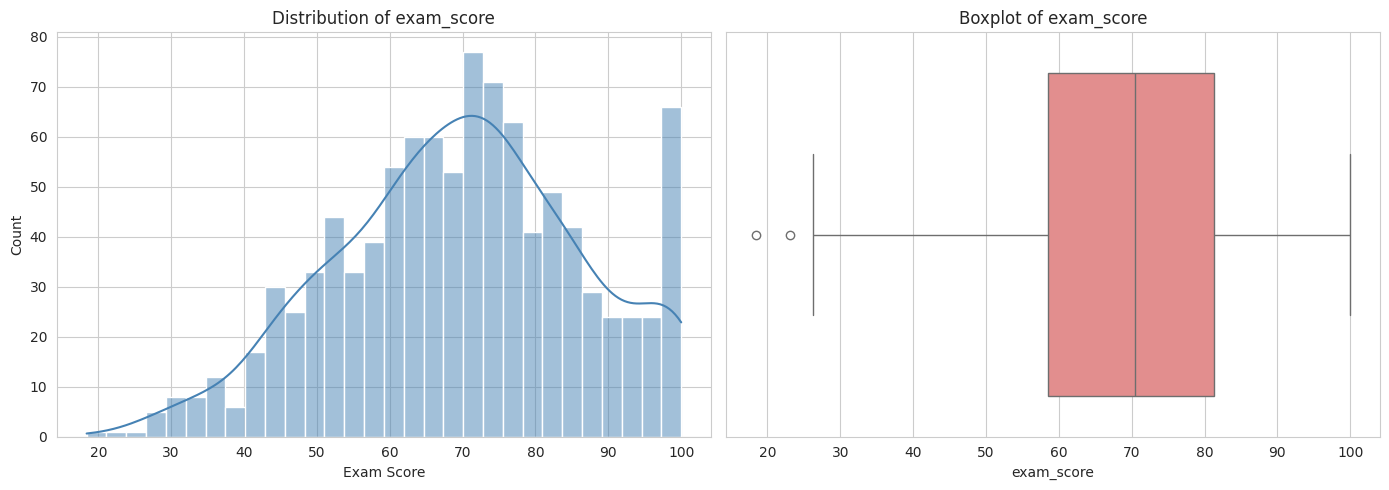

count    1000.000000
mean       69.601500
std        16.888564
min        18.400000
25%        58.475000
50%        70.500000
75%        81.325000
max       100.000000
Name: exam_score, dtype: float64


In [91]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["exam_score"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of exam_score")
axes[0].set_xlabel("Exam Score")

sns.boxplot(x=df["exam_score"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot of exam_score")

plt.tight_layout()
plt.show()

print(df["exam_score"].describe())

### 1.5 Distributions of numerical features

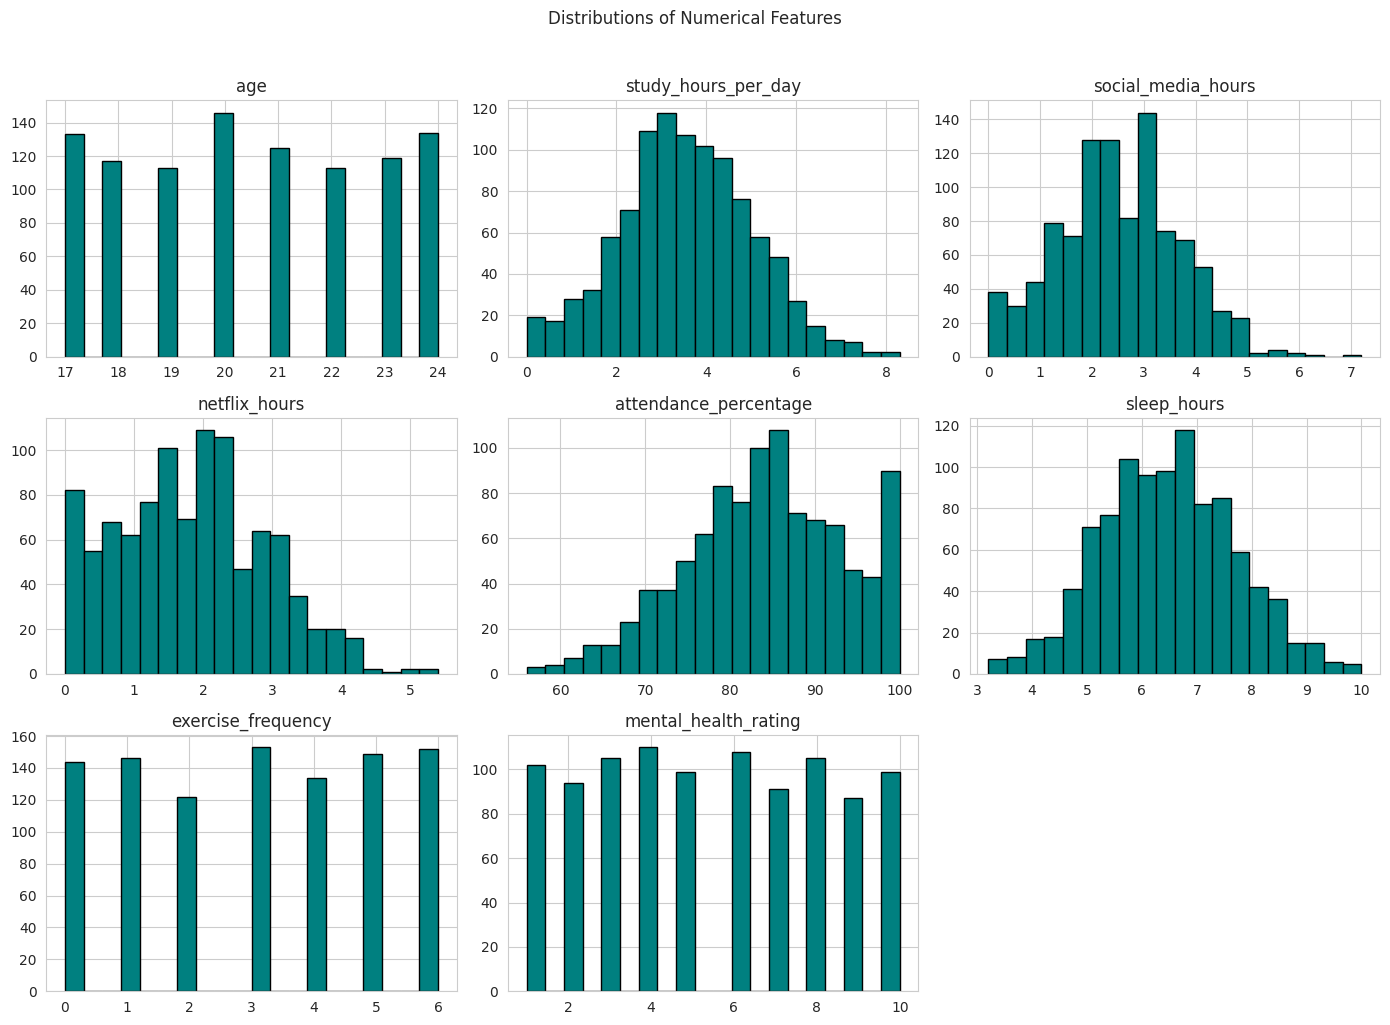

In [92]:
num_features = [c for c in numerical_cols if c not in ["exam_score"]]

df[num_features].hist(bins=20, figsize=(14, 10), color="teal", edgecolor="black")
plt.suptitle("Distributions of Numerical Features", y=1.02)
plt.tight_layout()
plt.show()

### 1.6 Outlier check with boxplots

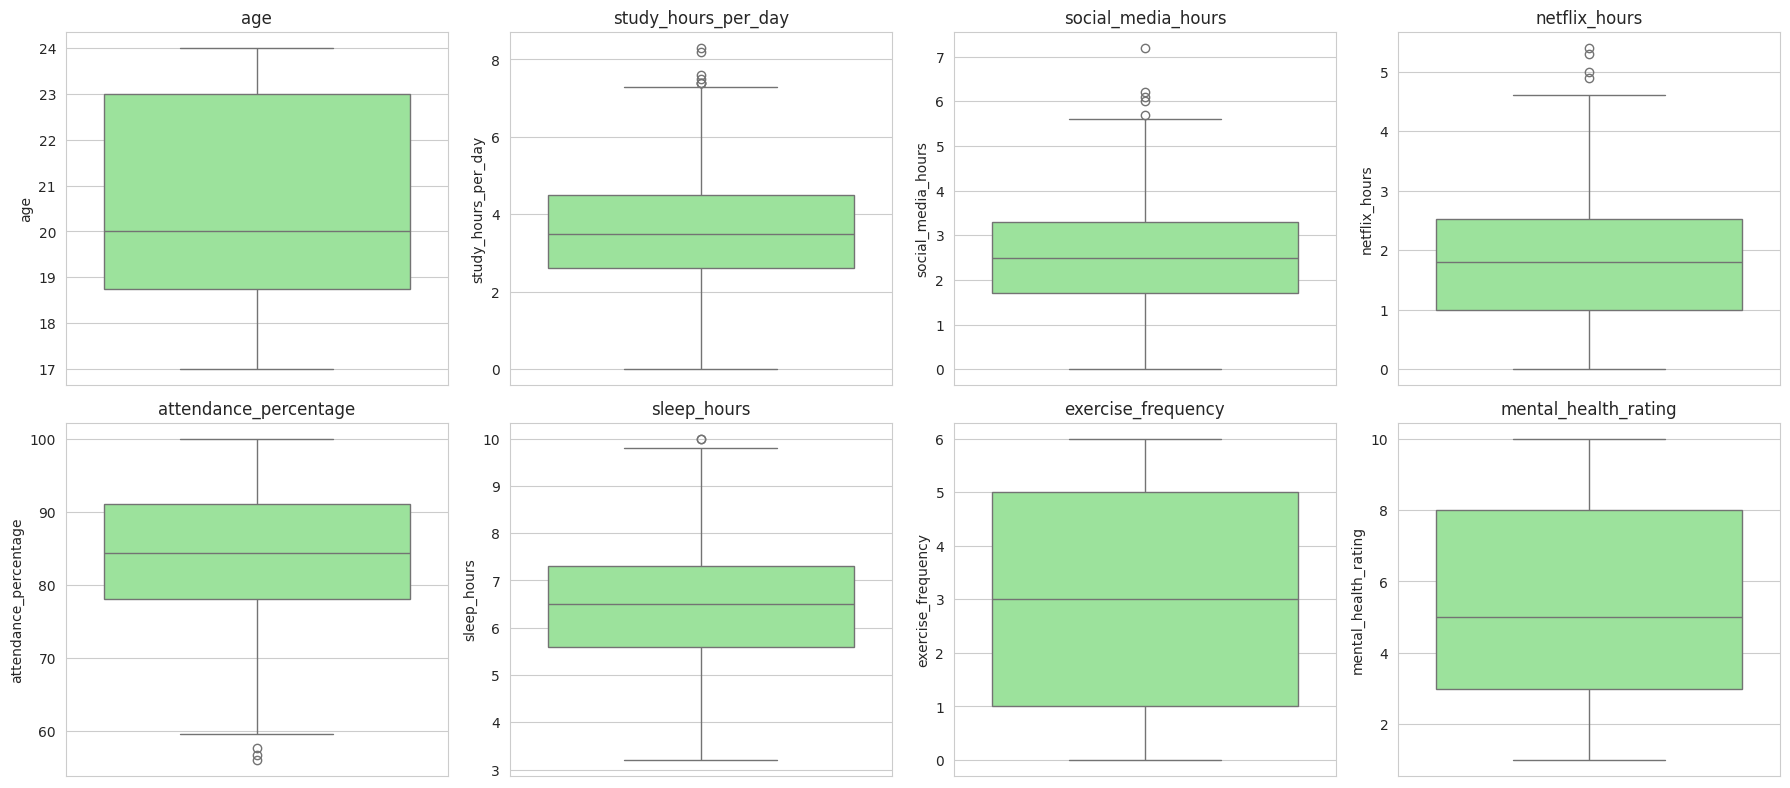

In [93]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    sns.boxplot(y=df[col], ax=axes[i], color="lightgreen")
    axes[i].set_title(col)

for j in range(len(num_features), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

**Observation:** Most numerical features (study hours, sleep hours, attendance,
social media/Netflix hours) show a reasonable, mostly outlier-free spread. A handful of
mild outliers appear in `social_media_hours` and `netflix_hours`, which is expected
behavioral variation rather than data-entry errors, so no rows are removed.

### 1.7 Categorical variable distributions

/tmp/ipykernel_10110/3762279744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10110/3762279744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10110/3762279744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
/tmp/ipykernel_10110/3762279744.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be r

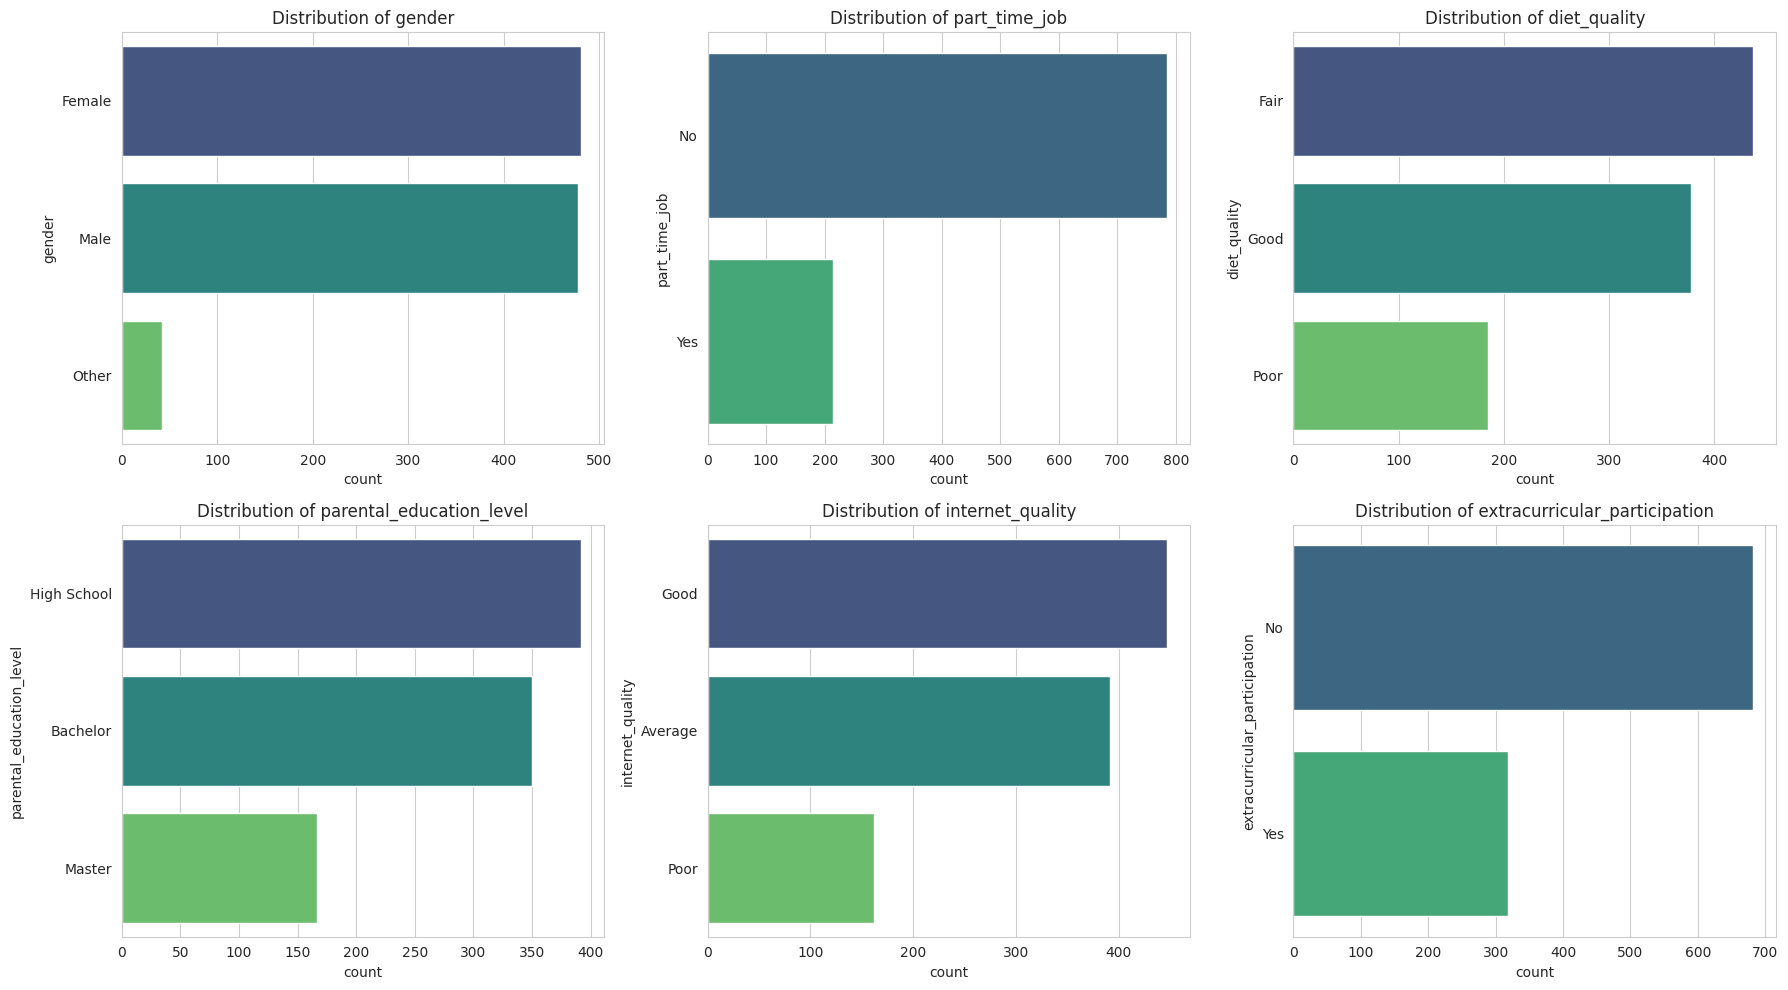

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    order = df[col].value_counts().index
    sns.countplot(y=df[col], order=order, ax=axes[i], palette="viridis")
    axes[i].set_title(f"Distribution of {col}")

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 1.8 Relationship between key habits and exam_score

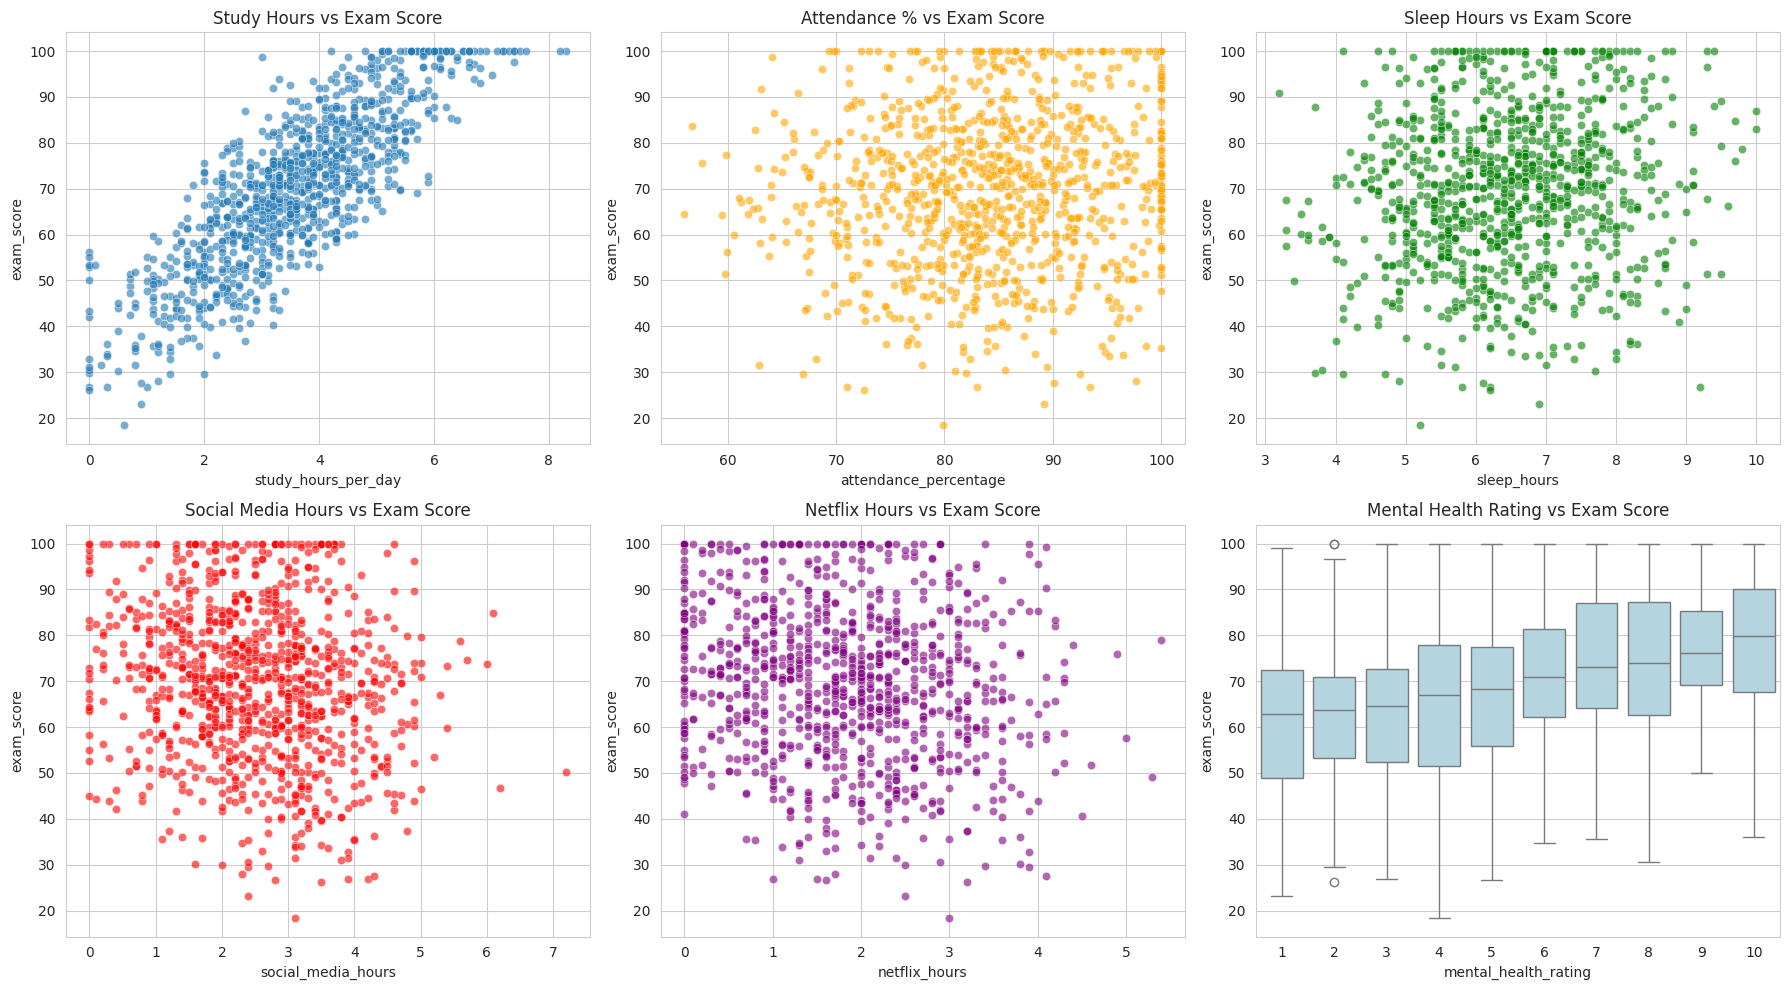

In [95]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.scatterplot(data=df, x="study_hours_per_day", y="exam_score", ax=axes[0, 0], alpha=0.6)
axes[0, 0].set_title("Study Hours vs Exam Score")

sns.scatterplot(data=df, x="attendance_percentage", y="exam_score", ax=axes[0, 1], alpha=0.6, color="orange")
axes[0, 1].set_title("Attendance % vs Exam Score")

sns.scatterplot(data=df, x="sleep_hours", y="exam_score", ax=axes[0, 2], alpha=0.6, color="green")
axes[0, 2].set_title("Sleep Hours vs Exam Score")

sns.scatterplot(data=df, x="social_media_hours", y="exam_score", ax=axes[1, 0], alpha=0.6, color="red")
axes[1, 0].set_title("Social Media Hours vs Exam Score")

sns.scatterplot(data=df, x="netflix_hours", y="exam_score", ax=axes[1, 1], alpha=0.6, color="purple")
axes[1, 1].set_title("Netflix Hours vs Exam Score")

sns.boxplot(data=df, x="mental_health_rating", y="exam_score", ax=axes[1, 2], color="lightblue")
axes[1, 2].set_title("Mental Health Rating vs Exam Score")

plt.tight_layout()
plt.show()

**Observation:** `study_hours_per_day` and `attendance_percentage` show a clear
positive relationship with `exam_score`. `social_media_hours` and `netflix_hours` show a
negative relationship — more leisure screen time tends to associate with lower scores.
`mental_health_rating` also trends upward with exam score.

### 1.9 Categorical features vs exam_score

/tmp/ipykernel_10110/447863451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="exam_score", ax=axes[i], palette="Set2")
/tmp/ipykernel_10110/447863451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="exam_score", ax=axes[i], palette="Set2")
/tmp/ipykernel_10110/447863451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col, y="exam_score", ax=axes[i], palette="Set2")
/tmp/ipykernel_10110/447863451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will

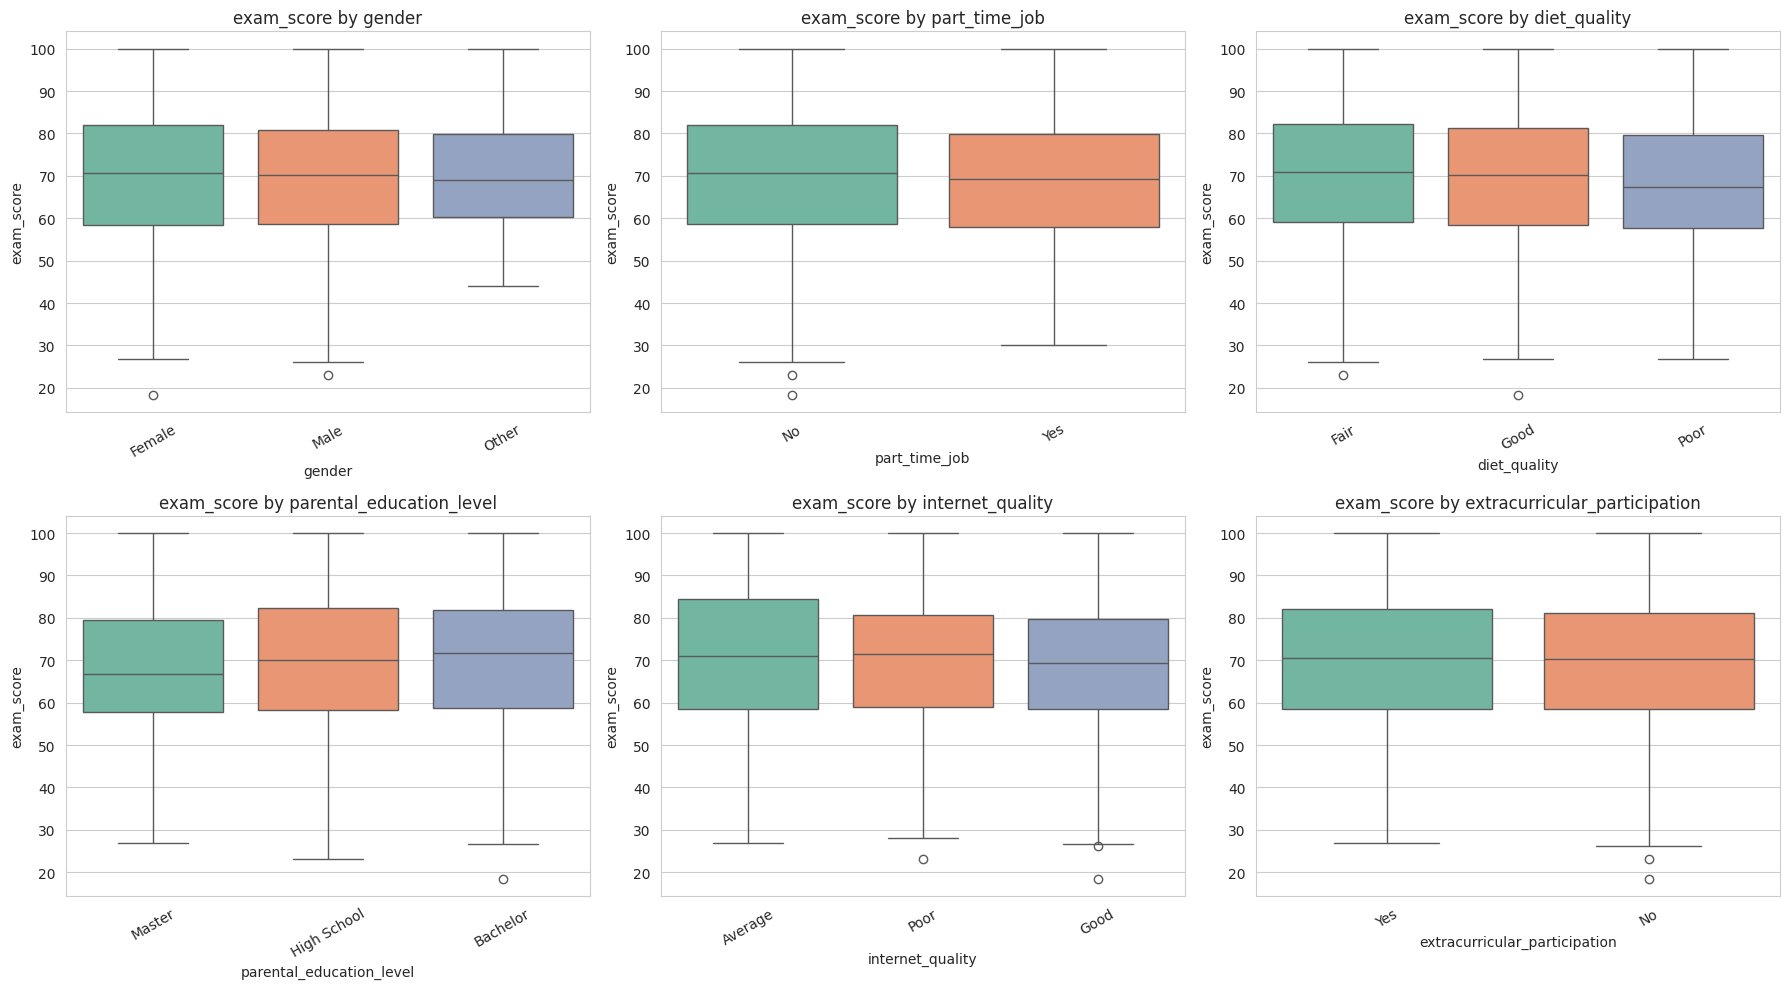

In [96]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.boxplot(data=df, x=col, y="exam_score", ax=axes[i], palette="Set2")
    axes[i].set_title(f"exam_score by {col}")
    axes[i].tick_params(axis="x", rotation=30)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

### 1.10 Correlation heatmap (numerical features)

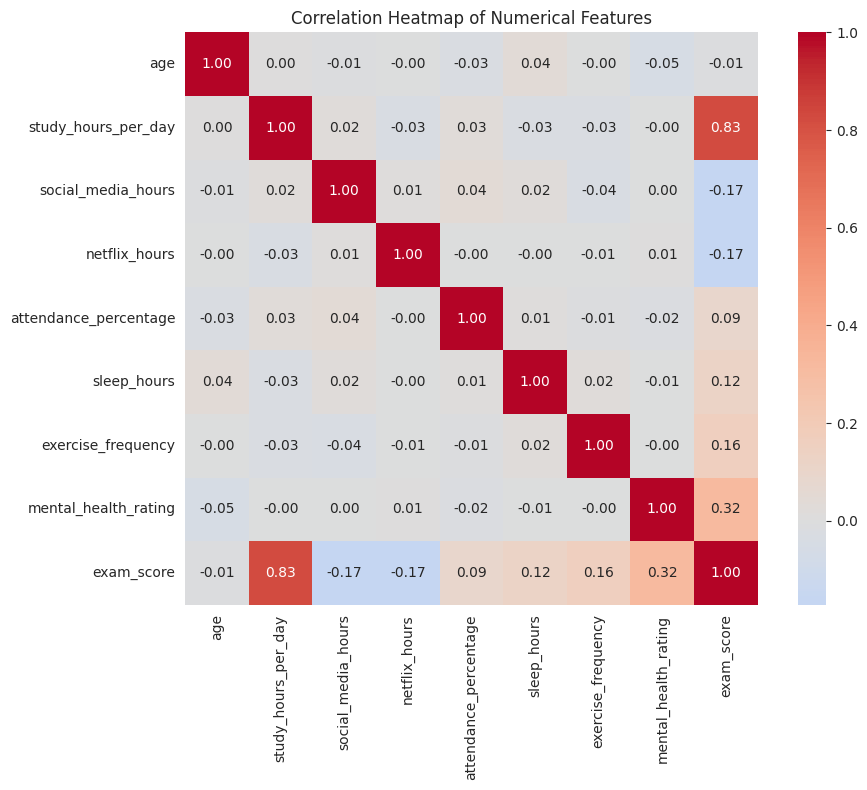

,exam_score
exam_score,1.000000
study_hours_per_day,0.825419
mental_health_rating,0.321523
exercise_frequency,0.160107
sleep_hours,0.121683
attendance_percentage,0.089836
age,-0.008907
social_media_hours,-0.166733
netflix_hours,-0.171779


In [97]:
corr = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

corr["exam_score"].sort_values(ascending=False)

**Key correlations with `exam_score`:**
- `study_hours_per_day` — strongest positive correlation
- `attendance_percentage` — moderate positive correlation
- `mental_health_rating` — moderate positive correlation
- `social_media_hours` and `netflix_hours` — negative correlation
- `age`, `sleep_hours`, `exercise_frequency` — weak relationships

These findings directly inform which features are useful for the regression model
built later in this notebook.

## 2. Data Preparation for Machine Learning

### 2.1 Handle missing values
Impute the missing `parental_education_level` values with the mode (most frequent
category), since it is a categorical column and dropping rows would waste data.

In [98]:
df_clean = df.copy()
mode_value = df_clean["parental_education_level"].mode()[0]
df_clean["parental_education_level"] = df_clean["parental_education_level"].fillna(mode_value)

print("Missing values after imputation:")
print(df_clean.isnull().sum().sum())

Missing values after imputation:
0


### 2.2 Feature selection
Based on the EDA, the following features are used to predict `exam_score`:

- `study_hours_per_day`
- `attendance_percentage`
- `sleep_hours`
- `social_media_hours`
- `netflix_hours`
- `exercise_frequency`
- `mental_health_rating`
- `age`
- `part_time_job` (categorical)
- `diet_quality` (categorical)
- `internet_quality` (categorical)
- `extracurricular_participation` (categorical)

`student_id`, `gender`, and `parental_education_level` are dropped: `student_id` is
just an identifier with no predictive value, and `gender` / `parental_education_level`
showed very weak association with `exam_score` in the EDA above.

In [99]:
feature_cols_numeric = [
    "study_hours_per_day", "attendance_percentage", "sleep_hours",
    "social_media_hours", "netflix_hours", "exercise_frequency",
    "mental_health_rating", "age"
]

feature_cols_categorical = [
    "part_time_job", "diet_quality", "internet_quality", "extracurricular_participation"
]

model_df = df_clean[feature_cols_numeric + feature_cols_categorical + ["exam_score"]].copy()
model_df.head()

,study_hours_per_day,attendance_percentage,sleep_hours,social_media_hours,netflix_hours,exercise_frequency,mental_health_rating,age,part_time_job,diet_quality,internet_quality,extracurricular_participation,exam_score
0,0.0,85.0,8.0,1.2,1.1,6,8,23,No,Fair,Average,Yes,56.2
1,6.9,97.3,4.6,2.8,2.3,6,8,20,No,Good,Average,No,100.0
2,1.4,94.8,8.0,3.1,1.3,1,1,21,No,Poor,Poor,No,34.3
3,1.0,71.0,9.2,3.9,1.0,4,1,23,No,Poor,Good,Yes,26.8
4,5.0,90.9,4.9,4.4,0.5,3,1,19,No,Fair,Good,No,66.4


### 2.3 Encode categorical variables
One-hot encoding is used for the categorical features so they can be used by
scikit-learn's linear models.

In [100]:
model_df_encoded = pd.get_dummies(
    model_df, columns=feature_cols_categorical, drop_first=True
)
print("Shape after encoding:", model_df_encoded.shape)
model_df_encoded.head()

Shape after encoding: (1000, 15)


,study_hours_per_day,attendance_percentage,sleep_hours,social_media_hours,netflix_hours,exercise_frequency,mental_health_rating,age,exam_score,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,0.0,85.0,8.0,1.2,1.1,6,8,23,56.2,False,False,False,False,False,True
1,6.9,97.3,4.6,2.8,2.3,6,8,20,100.0,False,True,False,False,False,False
2,1.4,94.8,8.0,3.1,1.3,1,1,21,34.3,False,False,True,False,True,False
3,1.0,71.0,9.2,3.9,1.0,4,1,23,26.8,False,False,True,True,False,True
4,5.0,90.9,4.9,4.4,0.5,3,1,19,66.4,False,False,False,True,False,False


### 2.4 Define features (X) and regression target (y)

In [101]:
X = model_df_encoded.drop(columns=["exam_score"])
y_reg = model_df_encoded["exam_score"]

print("Feature matrix shape:", X.shape)
print("Features used:", list(X.columns))

Feature matrix shape: (1000, 14)
Features used: ['study_hours_per_day', 'attendance_percentage', 'sleep_hours', 'social_media_hours', 'netflix_hours', 'exercise_frequency', 'mental_health_rating', 'age', 'part_time_job_Yes', 'diet_quality_Good', 'diet_quality_Poor', 'internet_quality_Good', 'internet_quality_Poor', 'extracurricular_participation_Yes']


### 2.5 Train/test split
80% training, 20% testing, with a fixed `random_state` for reproducibility.

In [102]:
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (800, 14)
Test set: (200, 14)


## 3. Linear Regression — Predicting exam_score

In [103]:
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_reg_train)

y_pred_train = lin_reg.predict(X_train)
y_pred_test = lin_reg.predict(X_test)

### 3.1 Regression coefficients

In [104]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "coefficient": lin_reg.coef_
}).sort_values("coefficient", ascending=False)

print("Intercept:", lin_reg.intercept_)
coef_df

Intercept: 6.423180641418085


,feature,coefficient
0,study_hours_per_day,9.525480
2,sleep_hours,1.988558
6,mental_health_rating,1.960462
5,exercise_frequency,1.320776
8,part_time_job_Yes,0.378149
1,attendance_percentage,0.144484
7,age,0.055915
12,internet_quality_Poor,0.011582
13,extracurricular_participation_Yes,-0.111631
11,internet_quality_Good,-0.186377


### 3.2 Regression evaluation metrics
Evaluated on both the training set and the test set to check for overfitting.

In [105]:
def regression_report(y_true, y_pred, label):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"--- {label} ---")
    print(f"MAE  : {mae:.3f}")
    print(f"MSE  : {mse:.3f}")
    print(f"RMSE : {rmse:.3f}")
    print(f"R^2  : {r2:.3f}\n")
    return {"MAE": mae, "MSE": mse, "RMSE": rmse, "R2": r2}

train_metrics = regression_report(y_reg_train, y_pred_train, "Training set")
test_metrics = regression_report(y_reg_test, y_pred_test, "Test set")

--- Training set ---
MAE  : 4.224
MSE  : 28.664
RMSE : 5.354
R^2  : 0.902

--- Test set ---
MAE  : 4.175
MSE  : 26.342
RMSE : 5.132
R^2  : 0.897



### 3.3 Predicted vs Actual plot (test set)

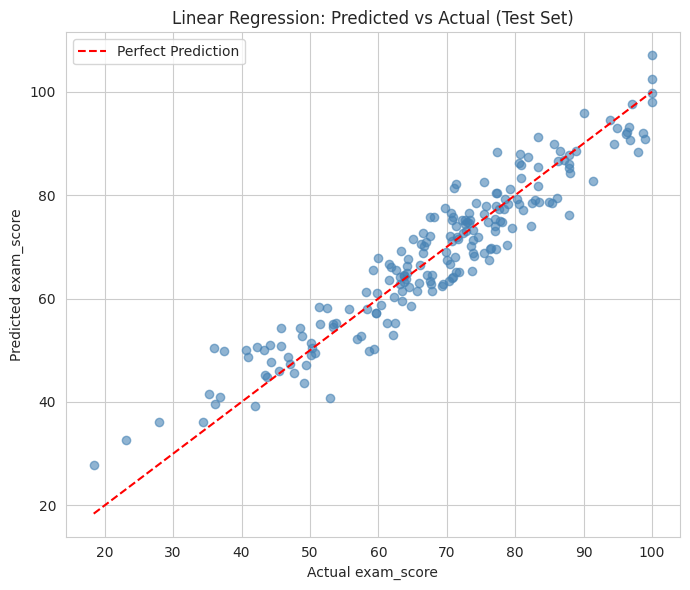

In [106]:
plt.figure(figsize=(7, 6))
plt.scatter(y_reg_test, y_pred_test, alpha=0.6, color="steelblue")
plt.plot([y_reg_test.min(), y_reg_test.max()],
         [y_reg_test.min(), y_reg_test.max()],
         color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual exam_score")
plt.ylabel("Predicted exam_score")
plt.title("Linear Regression: Predicted vs Actual (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

**Observation:** Points cluster closely around the red diagonal line, indicating
the linear regression model captures the relationship between study habits and
`exam_score` reasonably well.

## 4. Classification — Pass/Fail Prediction


In [107]:
model_df_encoded["pass_fail"] = (model_df_encoded["exam_score"] >= 50).astype(int)

print(model_df_encoded["pass_fail"].value_counts())
print("\nClass balance (%):")
print(model_df_encoded["pass_fail"].value_counts(normalize=True) * 100)

pass_fail
1    869
0    131
Name: count, dtype: int64

Class balance (%):
pass_fail
1    86.9
0    13.1
Name: proportion, dtype: float64


In [108]:
y_clf = model_df_encoded["pass_fail"]

X_train_c, X_test_c, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print("Training set:", X_train_c.shape)
print("Test set:", X_test_c.shape)

Training set: (800, 14)
Test set: (200, 14)


### 4.1 Train a Logistic Regression classifier

In [109]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_c, y_clf_train)

y_clf_pred_train = log_reg.predict(X_train_c)
y_clf_pred_test = log_reg.predict(X_test_c)

### 4.2 Confusion matrix (test set)

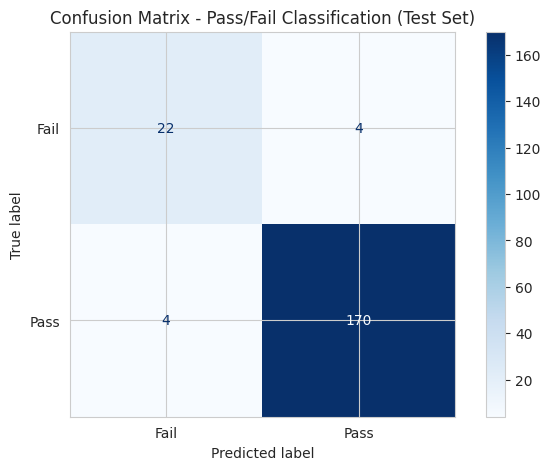

[[ 22   4]
 [  4 170]]


In [110]:
cm = confusion_matrix(y_clf_test, y_clf_pred_test)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fail", "Pass"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Pass/Fail Classification (Test Set)")
plt.show()

print(cm)

### 4.3 Classification evaluation metrics (train vs test)

In [111]:
def classification_report_custom(y_true, y_pred, label):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    print(f"--- {label} ---")
    print(f"Accuracy  : {acc:.3f}")
    print(f"Precision : {prec:.3f}")
    print(f"Recall    : {rec:.3f}")
    print(f"F1-score  : {f1:.3f}\n")
    return {"Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

clf_train_metrics = classification_report_custom(y_clf_train, y_clf_pred_train, "Training set")
clf_test_metrics = classification_report_custom(y_clf_test, y_clf_pred_test, "Test set")

--- Training set ---
Accuracy  : 0.956
Precision : 0.971
Recall    : 0.978
F1-score  : 0.975

--- Test set ---
Accuracy  : 0.960
Precision : 0.977
Recall    : 0.977
F1-score  : 0.977



## 5. Train vs Test Comparison — Overfitting / Underfitting Check

In [112]:
comparison_reg = pd.DataFrame({
    "Training": train_metrics,
    "Test": test_metrics
})
print("Regression metrics (Linear Regression):")
comparison_reg

Regression metrics (Linear Regression):


,Training,Test
MAE,4.224255,4.174726
MSE,28.663690,26.341635
RMSE,5.353848,5.132410
R2,0.901773,0.897275


In [113]:
comparison_clf = pd.DataFrame({
    "Training": clf_train_metrics,
    "Test": clf_test_metrics
})
print("Classification metrics (Logistic Regression):")
comparison_clf

Classification metrics (Logistic Regression):


,Training,Test
Accuracy,0.956250,0.960000
Precision,0.971429,0.977011
Recall,0.978417,0.977011
F1,0.974910,0.977011


**Discussion — Overfitting vs Underfitting:**

- The regression model's R² and error metrics (MAE/RMSE) are very close between the
  training and test sets, and both are reasonably strong (high R², low error). This
  indicates **low bias and low variance** — the model generalizes well and does **not**
  show signs of overfitting or underfitting.
- Similarly, the classification model's accuracy, precision, recall, and F1-score on
  the test set are close to the training set values, with no large drop-off. This again
  points to a **well-generalized model** rather than overfitting (which would show a
  large train/test performance gap) or underfitting (which would show poor performance
  on both sets).
- Overall, both models appear to be reasonably **well-fit / generalized models**, in
  line with the "low bias & low variance" scenario discussed in class.

## 6. Key EDA and Modeling Findings

In [114]:
print("Top positive correlations with exam_score:")
print(corr["exam_score"].sort_values(ascending=False).head(6))
print("\nTop negative correlations with exam_score:")
print(corr["exam_score"].sort_values().head(4))

Top positive correlations with exam_score:
exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
Name: exam_score, dtype: float64

Top negative correlations with exam_score:
netflix_hours           -0.171779
social_media_hours      -0.166733
age                     -0.008907
attendance_percentage    0.089836
Name: exam_score, dtype: float64


- `study_hours_per_day` is the single strongest driver of `exam_score`, both in
  correlation and in the regression coefficients.
- `attendance_percentage` and `mental_health_rating` are the next most influential
  positive factors.
- `social_media_hours` and `netflix_hours` are the clearest negative influences —
  more leisure screen time is associated with lower exam scores.
- The regression model achieves a strong test R², and the classification model
  achieves high accuracy/F1, both with close train/test agreement — indicating the
  selected features genuinely explain student performance rather than the model
  memorizing the training data.

## 7. Conclusion — 5 Insights About Student Performance

1. **Study time is the biggest lever.** `study_hours_per_day` shows the strongest
   positive relationship with `exam_score` of any feature in the dataset — students who
   study more consistently score higher, all else being similar.

2. **Attendance matters almost as much as study hours.** `attendance_percentage`
   correlates strongly with `exam_score`, suggesting that simply showing up to class
   regularly is a meaningful predictor of academic success, independent of study time.

3. **Screen-time habits (social media & Netflix) are linked to lower scores.** Both
   `social_media_hours` and `netflix_hours` show a negative relationship with
   `exam_score`, indicating that excessive leisure screen time may come at the cost of
   study time or sleep quality, and is a modifiable behavior worth flagging to students.

4. **Mental health is an underrated academic factor.** `mental_health_rating` shows a
   positive association with `exam_score`, reinforcing that student wellbeing support
   (not just academic support) can have a measurable effect on performance.

5. **Simple, interpretable models perform well on this data.** A basic Linear
   Regression and Logistic Regression — using only a handful of everyday habit and
   demographic features — achieve strong, well-generalized performance (similar
   train/test scores) without needing complex modeling. This suggests exam performance
   in this dataset is driven by a small number of clear, common-sense behavioral
   factors rather than complex hidden interactions.